In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts
import yaml

from pmt.io import *
from scipy.signal import find_peaks

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.fit import *
from pmt.fit.core import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# file_name = "WA0089_750V_525MHz_led100" 
# file_name = "WA0089_775V_525MHz_led100" 
# file_name = "WA0089_800V_525MHz_led100" 
file_name = "WA0089_825V_525MHz_led100"
# file_name = "WA0089_850V_525MHz_led100"
# file_name = "WA0089_875V_525MHz_led100" 
# file_name = "WA0089_900V_525MHz_led100"
# file_name = "WA0089_925V_525MHz_led100"
# file_name = "WA0089_950V_525MHz_led100"
# file_name = "WA0089_975V_525MHz_led100" 
# file_name = "WA0089_1000V_525MHz_led100" 

channel="Channel 4"
data_dir = Path("data/WA0089/voltage_sweep/260706")
# Set to a number for quick iteration, or None to use all matching files.
max_files = None

# save
save_plots = False
save_dir = 'plots/260706/fit'
file_nickname = file_name
fit_inputs = "fit_data"

save_fit_res = "fit_results"
savefit_path = Path(f"{save_dir}/{save_fit_res}")
savefit_path.mkdir(parents=True, exist_ok=True)


In [3]:
df_file = Path(fit_inputs) / f"{file_nickname}_df.pkl"

if df_file.exists():
    print(f"Loading cached dataframe from {df_file}")
    df = pd.read_pickle(df_file)
else:
    print("Creating dataframe from raw waveforms...")
    chunk_size = 512 
    baseline_window_ns = (0, 20)
    files = find_pmt_files(data_dir, file_name, max_files=max_files)
    for file in files:
        print(file)
    print(f"Number of files loaded: {len(files)}")
    time_ns, waveforms_mV, df = load_files_one_go( files, chunk_size, baseline_window_ns, channel )

print(df.shape)

Loading cached dataframe from fit_data/WA0089_825V_525MHz_led100_df.pkl
(59978, 33)


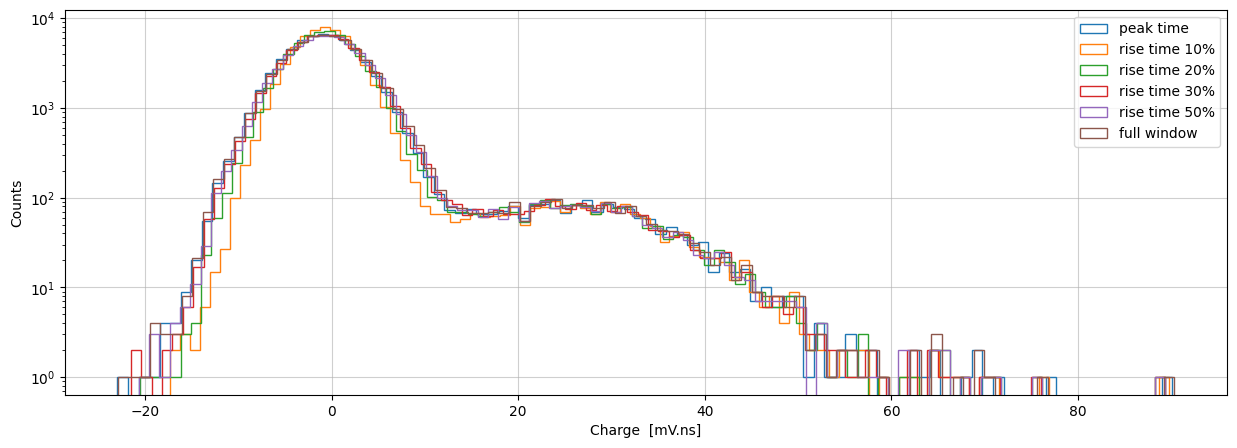

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.set_xlabel('Charge  [mV.ns]');
axes.set_ylabel('Counts');
axes.legend();




# Fit one step

In [5]:
charge_mV_ns = df.charge_cfd50_window_mV_ns.values # chose a charge distribution

fit_range_full = (np.min(charge_mV_ns), np.max(charge_mV_ns))
print(f"full range = ({fit_range_full[0]:.2f}, {fit_range_full[1]:.2f})")

full range = (-20.66, 89.36)


# Fit Config

optional: put all the initial parameter values and limits into a separate file (yaml format)

In [6]:
# with open('config_files/fit_config.yaml', 'r') as file:
#     cfg = yaml.safe_load(file)[file_nickname]
#     try:
#         fit_rg = cfg['fit_range']
#     except:
#         print('No fit range specified, using full range')
#         fit_rg = fit_range_full

# print(f'Fit range = {fit_rg}')

# p0_poisson = cfg['poisson']['initPars']
# p0_bellamy = cfg['bellamy']['initPars']


maxPE = 3 # how many photo electrons are expected in the distribution
nbins = 250

## Poisson

In [7]:
## if you don't want to use the config file:
# [mean value, lower bound, upper bound, is_fixed]
p0_poisson = {
    'q0_mV_ns': [-0.6, -6.0, 10.0, False],
    'sigma0_mV_ns': [3.9, '1e-4', 50.0, False],
    'q1_mV_ns': [29.0, 1.0, 40.0, False],
    'sigma1_mV_ns': [12.0, 0.2, 20.0, False],
    'mu_pe': [0.06, 0.001, 5.0, False]
}
fit_rg = fit_range_full

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total          59978.0000  59795.4291     244.5617     [29989.0, 89967.0]   False
mu_pe                0.0600      0.0343       0.0011             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.6706       0.0171           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.9599       0.0129            [0.0, 50.0]   False
q1_mV_ns            29.0000     23.4409       0.5022            [1.0, 40.0]   False
sigma1_mV_ns        12.0000     10.0174       0.3997            [0.2, 20.0]   False

 Gain is 2.93e+06 +-6.27e+04 for Q1 = 23.44091679011579


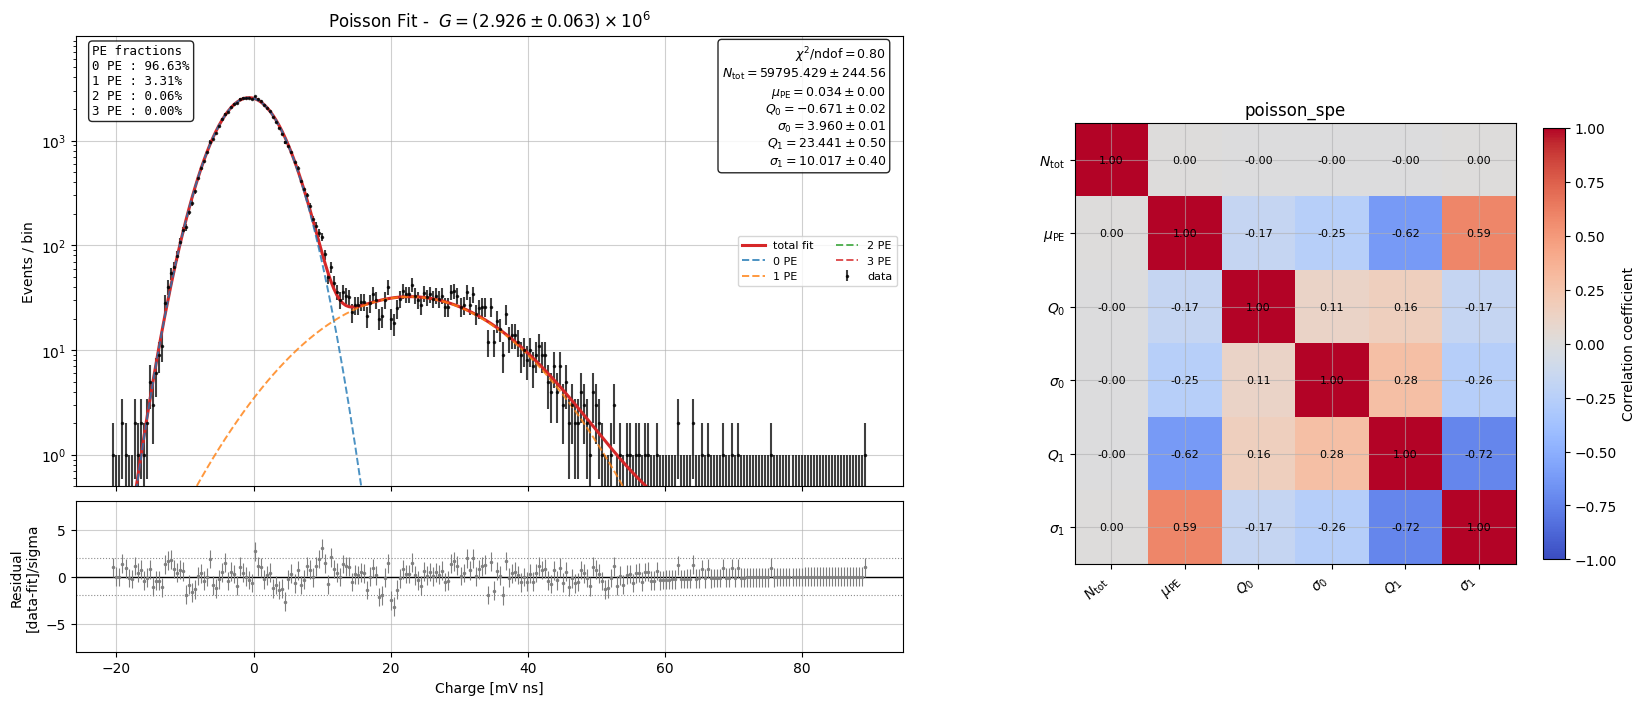

In [8]:
p0_poisson["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]

fit_poisson = fit_poisson_spe( charge_mV_ns, p0=p0_poisson, max_pe=maxPE, bins=nbins, fit_range=fit_rg )
print_fit_result_table(fit_poisson)
fit_poisson["diagnostics"]

G, G_err = compute_gain(fit_poisson['parameters']['q1_mV_ns'], fit_poisson['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_poisson['parameters']['q1_mV_ns']}")
exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Poisson Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_poisson, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson_{nbins}bins",  Nevents=None);

save_fit_results(fit_poisson, output_path=f"{savefit_path}/{file_nickname}_poisson.yaml")


## Bellamy

In [9]:
p0_bellamy = {
    'q0_mV_ns': [-0.6, -6.0, 10.0, False],
    'sigma0_mV_ns': [3.9, '1e-4', 50.0, False],
    'q1_mV_ns': [30.0, 5.0, 50.0, False],
    'sigma1_mV_ns': [12.0, 0.2, 30.0, False],
    'mu_pe': [0.06, 0.001, 5.0, False],
    'w': [0.2, 0.0, 1.0, False],
    'alpha': [0.3, 0.0, 10.0, False]
 }
fit_rg = fit_range_full

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total          59978.0000  59820.8878     244.6075     [29989.0, 89967.0]   False
mu_pe                0.0600      0.0272       0.0032             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.7826       0.0605           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.9022       0.0247            [0.0, 50.0]   False
q1_mV_ns            30.0000     26.6110       1.1434            [5.0, 50.0]   False
sigma1_mV_ns        12.0000      8.0629       0.6567            [0.2, 30.0]   False
w                    0.2000      0.0462       0.0266             [0.0, 1.0]   False
alpha                0.3000      0.2350       0.1254            [0.0, 10.0]   False
[]

 Gain is 3.32e+06 +-1.43e+05 for Q1 = 26.61104717569769


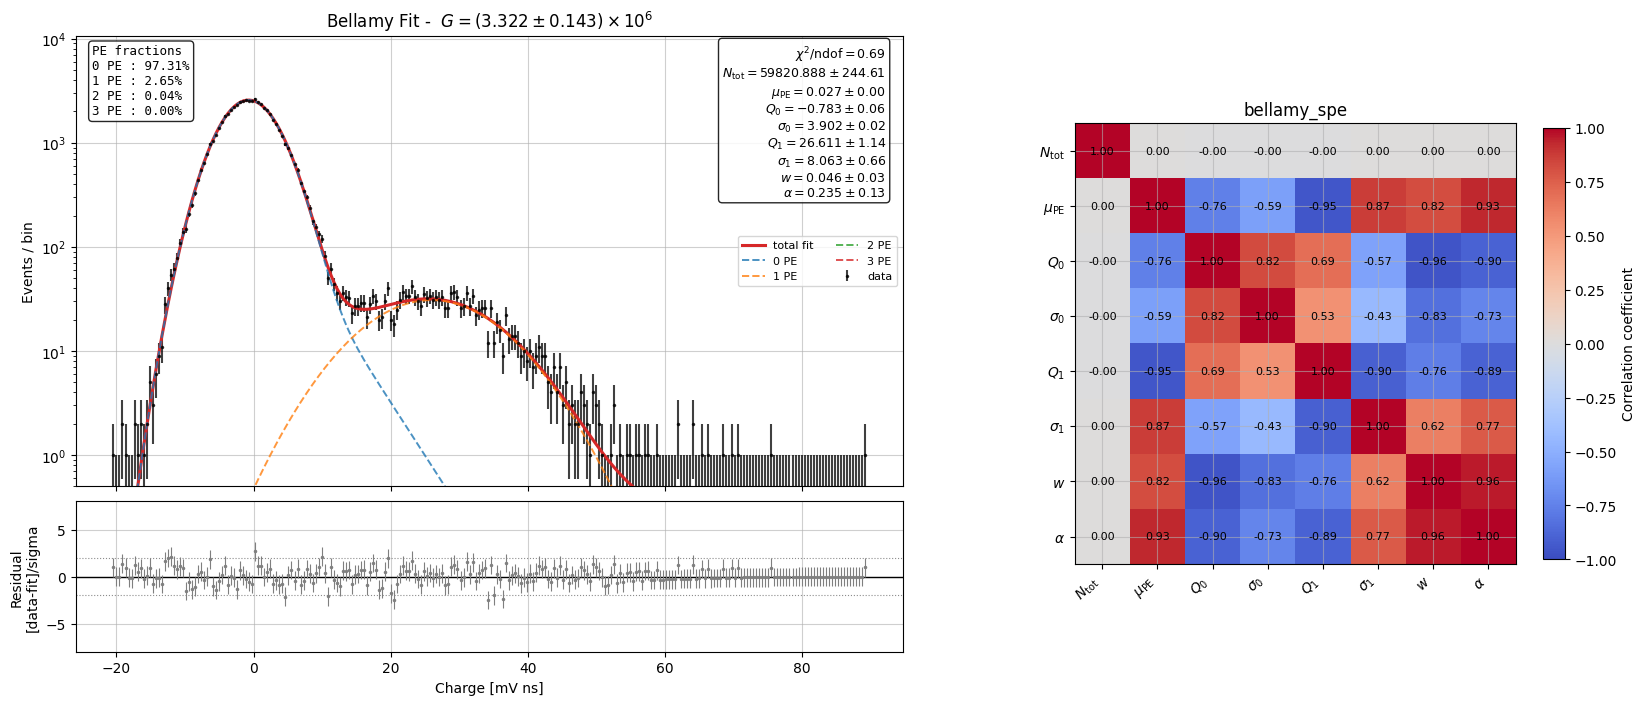

In [10]:
p0_bellamy["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]
fit_bellamy = fit_bellamy_spe( charge_mV_ns, p0=p0_bellamy, max_pe=maxPE, bins=nbins, fit_range=fit_rg)

print_fit_result_table(fit_bellamy)
print(fit_bellamy["diagnostics"])

G, G_err = compute_gain(fit_bellamy['parameters']['q1_mV_ns'], fit_bellamy['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_bellamy['parameters']['q1_mV_ns']}")

exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Bellamy Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_bellamy, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy_{nbins}bins",  Nevents=None);
save_fit_results(fit_bellamy, output_path=f"{savefit_path}/{file_nickname}_bellamy.yaml")


